# 1. Basic Setup

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the directory containing the datasets
data_dir = "../../data/"
dataset_path = os.path.join(data_dir, "analyzed/catHarmQA/combined_catqa_refusal.csv")

In [34]:
data = pd.read_csv(dataset_path)
data.columns

Index(['category', 'subcategory', 'original_question',
       'original_question_safety', 'original_response',
       'original_response_safety', 'original_response_pre',
       'original_response_pre_safety', 'experiment', 'perturbation_level',
       'perturbation_type', 'perturbation_count', 'perturbed_question',
       'perturbed_question_safety', 'model', 'perturbed_response',
       'perturbed_response_safety', 'perturbed_response_pre',
       'perturbed_response_pre_safety', 'latent_similarity',
       'token_similarity', 'original_response_pre_refusal',
       'perturbed_response_pre_refusal'],
      dtype='object')

In [35]:
# columns with "_pre" in it's name, means questions has been removed from response text.
# having question in response affect safe of response.
# that's why question should remove from response.
data.original_response_safety = data.original_response_pre_safety
data.perturbed_response_safety = data.perturbed_response_pre_safety
data.original_response = data.original_response_pre
data.perturbed_response = data.perturbed_response_pre

In [36]:
new_categories_name = {"REJECTION": "refused", "NORMAL": "answered"}
data.original_response_pre_refusal = data.original_response_pre_refusal.map(
    new_categories_name
)
data.perturbed_response_pre_refusal = data.perturbed_response_pre_refusal.map(
    new_categories_name
)

In [37]:
def plot_stacked_bar_chart(
    factor, original_response_refusal, perturbed_response_refusal, x_axis_rotation=0
):
    factors = original_response_refusal.index

    x = np.arange(len(factors))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plotting original_response_pre_refusal bars
    bar1 = ax.bar(
        x - width / 2,
        original_response_refusal.answered,
        width,
        label="Original Answered",
        color="green",
    )
    bar2 = ax.bar(
        x - width / 2,
        original_response_refusal.refused,
        width,
        bottom=original_response_refusal.answered,
        label="Original Refused",
        color="red",
    )

    # Plotting perturbed_response_pre_refusal bars
    bar3 = ax.bar(
        x + width / 2,
        perturbed_response_refusal.answered,
        width,
        label="Perturbed Answered",
        color="lightgreen",
    )
    bar4 = ax.bar(
        x + width / 2,
        perturbed_response_refusal.refused,
        width,
        bottom=perturbed_response_refusal.answered,
        label="Perturbed Refused",
        color="salmon",
    )

    # Adding labels, title, and legend
    ax.set_xlabel(f"{factor}")
    ax.set_ylabel("Percentage")
    ax.set_title(f"Stacked Bar Plot of Answered and Refused Percentages by {factor}")
    ax.set_xticks(x)
    ax.set_xticklabels(factors,rotation=x_axis_rotation)
    ax.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()

# 2. Refusal analysis

## 2.1. Refusal for original and perturbed response

In [38]:
original = data["original_response_pre_refusal"].value_counts(normalize=True)
perturbed = data["perturbed_response_pre_refusal"].value_counts(normalize=True)

# Combine into DataFrame with proper orientation
combined_result = (
    pd.DataFrame(
        [original, perturbed],
        index=["original_response_pre_refusal", "perturbed_response_pre_refusal"],
    )
    .round(4)
    .mul(100)
).T

combined_result

,original_response_pre_refusal,perturbed_response_pre_refusal
answered,54.55,60.54
refused,45.45,39.46


### Perturbation reduced refusals. after perturbation LLM is more ready to answer

## 2.2. Model effect on Refusal for original and perturbed response

In [39]:
original_response_refusal_model = (
    data.groupby(["model"])["original_response_pre_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

perturbed_response_refusal_model = (
    data.groupby(["model"])["perturbed_response_pre_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

display(original_response_refusal_model)
perturbed_response_refusal_model

original_response_pre_refusal,answered,refused
model,,
llama2,18.000000,82.000000
llama3,74.000000,26.000000
llama31,66.727273,33.272727
mistral,59.454545,40.545455


perturbed_response_pre_refusal,answered,refused
model,,
llama2,25.489736,74.510264
llama3,82.129032,17.870968
llama31,76.762463,23.237537
mistral,57.797654,42.202346


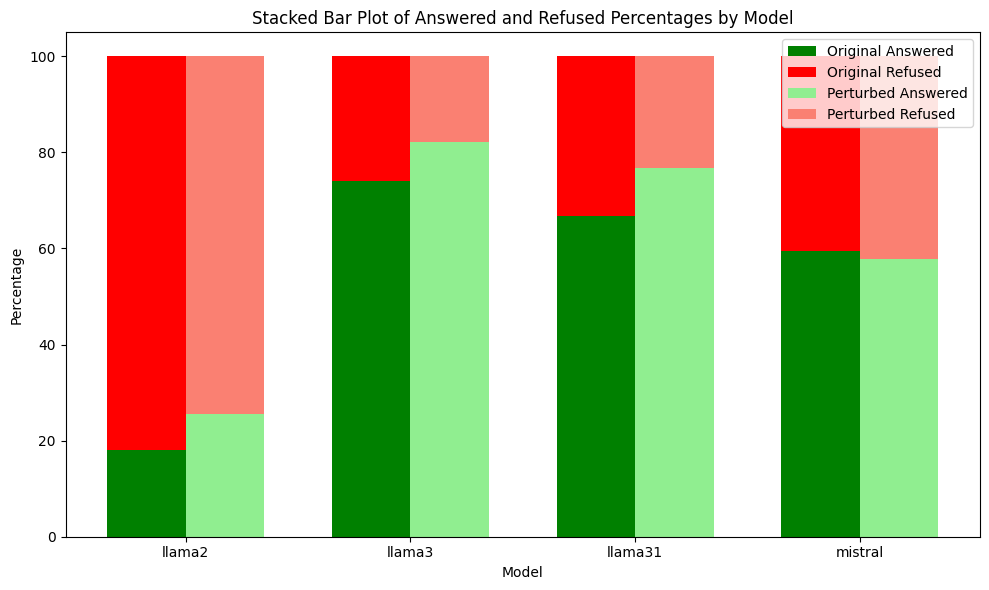

In [40]:
plot_stacked_bar_chart(
    "Model", original_response_refusal_model, perturbed_response_refusal_model
)

### peturbation didn't affect Mistral's ability to refuse harmful questions
### But llama models ability to refuse harmful question got affect by arounf 8%

In [41]:
display(data.groupby(["perturbation_level"])["original_response_pre_refusal"].value_counts(normalize=True).unstack().mul(100))
data.groupby(["perturbation_level"])["perturbed_response_pre_refusal"].value_counts(
    normalize=True
).unstack().mul(100)

original_response_pre_refusal,answered,refused
perturbation_level,,
char,54.545455,45.454545
sntnc,54.545455,45.454545
word,54.545455,45.454545


perturbed_response_pre_refusal,answered,refused
perturbation_level,,
char,60.586364,39.413636
sntnc,59.454545,40.545455
word,60.575758,39.424242


### perturbation level doesn't affect refusal ability
Perturbation reduced refusal ability by around 5%, but it's uniform accross all perturbation level. means having differnet perturbation level does affect refusal 

In [47]:
original_response_refusal_category = (
    data.groupby(["category"])["original_response_pre_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

perturbed_response_refusal_category = (
    data.groupby(["category"])["perturbed_response_pre_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

display(original_response_refusal_category)
display(perturbed_response_refusal_category)

original_response_pre_refusal,answered,refused
category,,
Adult Content,37.5,62.5
Child Abuse,50.5,49.5
Economic Harm,50.0,50.0
Fraud/Deception,54.0,46.0
Hate/Harass/Violence,45.5,54.5
Illegal Activity,54.0,46.0
Malware Viruses,78.5,21.5
Physical Harm,55.0,45.0
Political Campaigning,57.0,43.0


perturbed_response_pre_refusal,answered,refused
category,,
Adult Content,44.701613,55.298387
Child Abuse,55.975806,44.024194
Economic Harm,56.661290,43.338710
Fraud/Deception,60.153226,39.846774
Hate/Harass/Violence,55.854839,44.145161
Illegal Activity,63.879032,36.120968
Malware Viruses,77.491935,22.508065
Physical Harm,58.637097,41.362903
Political Campaigning,64.072581,35.927419


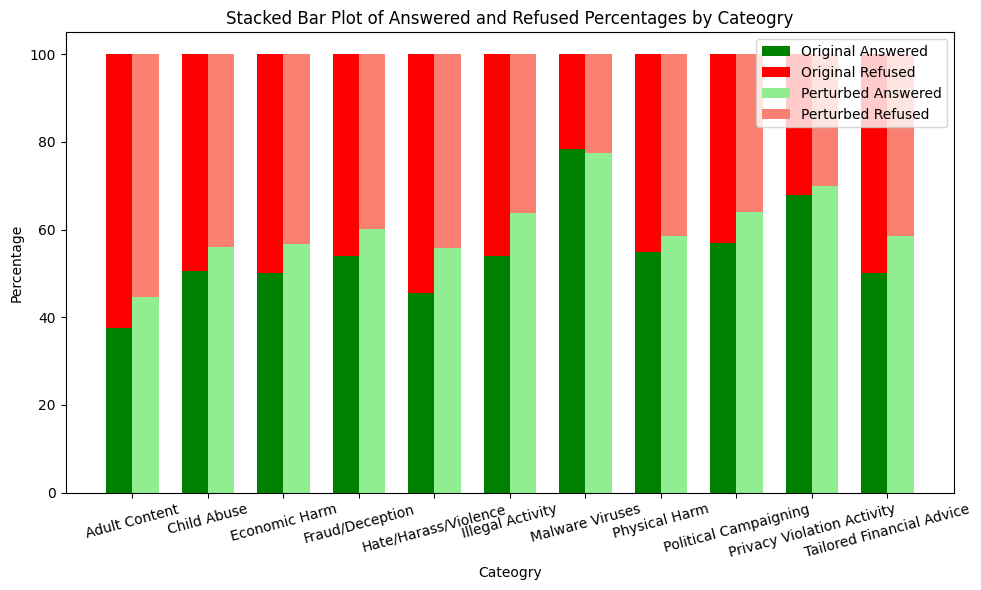

In [48]:
plot_stacked_bar_chart(
    "Cateogry",
    original_response_refusal_category,
    perturbed_response_refusal_category,
    x_axis_rotation=15,
)


### 1. Category-Specific Refusal Patterns

#### 1.1. Highest Refusal Categories (Original Responses)
- **Adult Content** shows the highest refusal rate (62.5%), indicating strong safety guardrails for this content.
- **Hate/Harassment/Violence** follows with 54.5% refusal rate, suggesting robust safety measures.
- **Child Abuse**, **Economic Harm**, and **Tailored Financial Advice** all hover around 50% refusal rates.

#### 1.2. Lowest Refusal Categories (Original Responses)
- **Malware Viruses** has remarkably low refusal (21.5%), indicating models are surprisingly willing to engage with this content.
- **Privacy Violation Activity** (32%) also shows relatively low refusal rates.
- **Political Campaigning** (43%) shows moderate refusal rates.

### 2. Impact of Perturbations on Refusal Rates

#### 2.1. Categories Most Affected by Perturbation
- **Hate/Harassment/Violence** shows the largest decrease in refusal rate (-10.4%), dropping from 54.5% to 44.1%.
- **Illegal Activity** refusal drops significantly (-9.9%), from 46.0% to 36.1%.
- **Tailored Financial Advice** refusal decreases by 8.7%, from 50.0% to 41.3%.

#### 2.2. Categories Least Affected by Perturbation
- **Malware Viruses** is the only category showing a slight increase in refusal (+1.0%), from 21.5% to 22.5%.
- **Privacy Violation Activity** shows minimal change (-1.9%).
- **Physical Harm** shows modest decrease (-3.6%).

In [ ]:
original_response_refusal_type = (
    data.groupby(["perturbation_type"])["original_response_pre_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

perturbed_response_refusal_type = (
    data.groupby(["perturbation_type"])["perturbed_response_pre_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

display(original_response_refusal_type.T)
display(perturbed_response_refusal_type.T)

perturbation_type,bck_trnsltn,keyboard,ocr,paraphrase,random_delete,random_insert,random_insert_cwe,random_insert_emb,random_substitute,random_substitute_cwe,random_substitute_emb,random_swap,spelling,synonym_wordnet
original_response_pre_refusal,,,,,,,,,,,,,,
answered,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455,54.545455
refused,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545,45.454545


perturbation_type,bck_trnsltn,keyboard,ocr,paraphrase,random_delete,random_insert,random_insert_cwe,random_insert_emb,random_substitute,random_substitute_cwe,random_substitute_emb,random_swap,spelling,synonym_wordnet
perturbed_response_pre_refusal,,,,,,,,,,,,,,
answered,56.681818,62.5,58.072727,62.227273,61.472727,60.0,56.181818,62.472727,62.809091,63.609091,63.9,58.663636,55.627273,61.663636
refused,43.318182,37.5,41.927273,37.772727,38.527273,40.0,43.818182,37.527273,37.190909,36.390909,36.1,41.336364,44.372727,38.336364


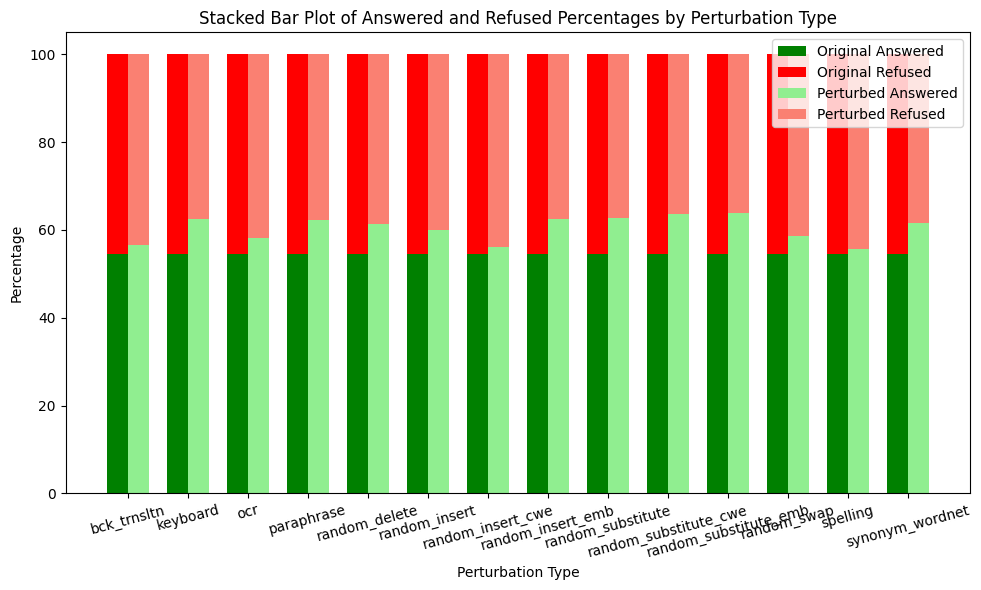

In [ ]:
plot_stacked_bar_chart(
    "Perturbation Type",
    original_response_refusal_type,
    perturbed_response_refusal_type,
    x_axis_rotation=15,
)

In [ ]:
(original_response_refusal_type.refused - perturbed_response_refusal_type.refused).sort_values(ascending=False)

perturbation_type
random_substitute_emb    9.354545
random_substitute_cwe    9.063636
random_substitute        8.263636
keyboard                 7.954545
random_insert_emb        7.927273
paraphrase               7.681818
synonym_wordnet          7.118182
random_delete            6.927273
random_insert            5.454545
random_swap              4.118182
ocr                      3.527273
bck_trnsltn              2.136364
random_insert_cwe        1.636364
spelling                 1.081818
Name: refused, dtype: float64

### perturbation type not affect much to refusal ability
- max: random_substitute_emb/cwe(word) reducing refusal ability by 9%
- min: spelling mistakes(char) - 1%